In [28]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from helper_function import plot_decision_boundary, accuracy_fn

In [29]:
X, y = load_breast_cancer(return_X_y = True)

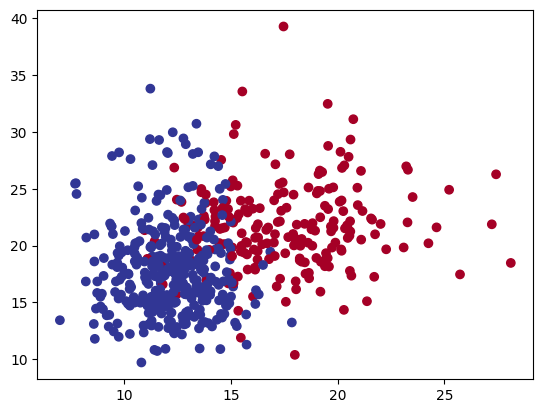

In [30]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [31]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [32]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [34]:
X_train.shape, y_train.unique()

(torch.Size([455, 30]), tensor([0., 1.]))

In [35]:
class BreastCancerClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(in_features = 30, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 32),
            nn.ReLU(),
            nn.Linear(in_features = 32, out_features = 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [36]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [37]:
model = BreastCancerClassification().to(device)
model

BreastCancerClassification(
  (layer): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [38]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test.to(device))
    y_pred = torch.sigmoid(y_logits).argmax(dim=1)

y_pred.unique()

tensor([0], device='mps:0')

In [39]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [40]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [43]:
epochs = 1000
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_logits))
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 3.964703321456909 | Test Loss: 232.58853149414062
Train Accuracy: 62.857142857142854 | Test Accuracy: 37.719298245614034

Train Loss: 0.6597126126289368 | Test Loss: 0.662727952003479
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597115397453308 | Test Loss: 0.6627442240715027
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597115397453308 | Test Loss: 0.6627442240715027
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597115397453308 | Test Loss: 0.6627441644668579
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597116589546204 | Test Loss: 0.6627442240715027
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597116589546204 | Test Loss: 0.6627442240715027
Train Accuracy: 62.857142857142854 | Test Accuracy: 62.28070175438597

Train Loss: 0.6597116589546204 | Test Loss: 0.6627442240715027
